# UC2 — Gemelo Digital: Feature Engineering
**Author:** Brayan Ivan  
**Project:** Datamoles — Havi, copiloto financiero proactivo (DSC x Hey 2026)  
**Goal:** Build a rich, multi-dimensional behavioral feature vector per user.  
This feature matrix is the raw material for the digital twin clustering in the next notebook.  

**Blocks:**
| # | Block | Prefix | Description |
|---|-------|--------|-------------|
| 2 | Demografía | `feat_dem_*` | Age, income, bureau score, seniority |
| 3 | Engagement Hey | `feat_eng_*` | Product adoption, NPS, login recency |
| 4 | Portafolio | `feat_port_*` | Active products, investments, credit |
| 5 | Comportamiento Transaccional | `feat_txn_*` | Spend, frequency, ticket size |
| 6 | MCC | `feat_mcc_*` | Category mix & concentration |
| 7 | Temporal | `feat_time_*` | Hour/day patterns |
| 8 | Canal | `feat_chn_*` | Channel preferences |
| 9 | Riesgo | `feat_risk_*` | Rejections, disputes, retries |

## 0. Setup

In [1]:
# Author: Brayan Ivan | UC2 — Gemelo Digital: Feature Engineering
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# UC2 uses FULL history — the digital twin needs the complete behavioral record
CUTOFF_DATE = pd.Timestamp("2025-10-31")

BASE_TXN = Path("/Users/diegodq/Documents/dev/datamoles/Datathon-2026/Datathon_Hey_2026_dataset_transacciones 1/dataset_transacciones")
OUTPUT_DIR = Path("/Users/diegodq/Documents/dev/datamoles/Datathon-2026/outputs/features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"CUTOFF_DATE : {CUTOFF_DATE.date()}")
print(f"BASE_TXN    : {BASE_TXN}")
print(f"OUTPUT_DIR  : {OUTPUT_DIR}")

CUTOFF_DATE : 2025-10-31
BASE_TXN    : /Users/diegodq/Documents/dev/datamoles/Datathon-2026/Datathon_Hey_2026_dataset_transacciones 1/dataset_transacciones
OUTPUT_DIR  : /Users/diegodq/Documents/dev/datamoles/Datathon-2026/outputs/features


## 1. Carga de datos
Load all three CSVs and the transacciones parquet/csv files, apply gotchas, parse dates, and filter to CUTOFF.

In [2]:
%%time
# ── Rutas base ────────────────────────────────────────────────────────────────
BASE_DATA = BASE_TXN  # fixed: clientes/productos CSVs are in BASE_TXN

df_clientes   = pd.read_csv(BASE_DATA / "hey_clientes.csv",   low_memory=False)
df_productos  = pd.read_csv(BASE_DATA / "hey_productos.csv",  low_memory=False)

# Transacciones puede venir como CSV suelto o carpeta con particiones
txn_csv = BASE_DATA / "hey_transacciones.csv"
if txn_csv.exists():
    df_tx = pd.read_csv(txn_csv, low_memory=False)
else:
    # Carpeta con particiones .csv o .parquet
    parts_csv = list(BASE_TXN.glob("*.csv"))
    parts_pq  = list(BASE_TXN.glob("*.parquet"))
    if parts_csv:
        df_tx = pd.concat([pd.read_csv(p, low_memory=False) for p in parts_csv], ignore_index=True)
    elif parts_pq:
        df_tx = pd.concat([pd.read_parquet(p) for p in parts_pq], ignore_index=True)
    else:
        raise FileNotFoundError(f"No transaction files found in {BASE_TXN}")

print("Shapes raw:")
print(f"  clientes    : {df_clientes.shape}")
print(f"  productos   : {df_productos.shape}")
print(f"  transacciones: {df_tx.shape}")

Shapes raw:
  clientes    : (15025, 22)
  productos   : (38909, 13)
  transacciones: (802384, 22)
CPU times: user 1.44 s, sys: 121 ms, total: 1.56 s
Wall time: 1.56 s


In [3]:
%%time
# ── Gotchas — clientes ────────────────────────────────────────────────────────
# Drop synthetic data flag (not a real feature)
if 'es_dato_sintetico' in df_clientes.columns:
    df_clientes.drop(columns=['es_dato_sintetico'], inplace=True)

# Rename ambiguous column to avoid collision on merge
if 'patron_uso_atipico' in df_clientes.columns:
    df_clientes.rename(columns={'patron_uso_atipico': 'patron_uso_atipico_user'}, inplace=True)

# Parse date columns dynamically
for col in df_clientes.columns:
    if 'fecha' in col.lower() or 'conexion' in col.lower() or 'alta' in col.lower():
        df_clientes[col] = pd.to_datetime(df_clientes[col], errors='coerce')

# Imputations
if 'satisfaccion_1_10' in df_clientes.columns:
    df_clientes['satisfaccion_1_10'].fillna(7.0, inplace=True)  # impute with median 7.0
for col in ['estado', 'ciudad']:
    if col in df_clientes.columns:
        df_clientes[col].fillna('Desconocido', inplace=True)

# ── Gotchas — transacciones ───────────────────────────────────────────────────
if 'es_dato_sintetico' in df_tx.columns:
    df_tx.drop(columns=['es_dato_sintetico'], inplace=True)

if 'patron_uso_atipico' in df_tx.columns:
    df_tx.rename(columns={'patron_uso_atipico': 'patron_uso_atipico_txn'}, inplace=True)

# Parse transaction datetime
date_col_tx = None
for col in ['fecha_hora', 'fecha', 'fecha_transaccion']:
    if col in df_tx.columns:
        df_tx[col] = pd.to_datetime(df_tx[col], errors='coerce')
        date_col_tx = col
        break

if date_col_tx is None:
    raise ValueError("No date column found in transacciones. Inspect df_tx.columns")

print(f"Date column in transacciones: '{date_col_tx}'")

# UC2: use FULL history up to CUTOFF
df_tx = df_tx[df_tx[date_col_tx] <= CUTOFF_DATE].copy()
print(f"Transacciones after CUTOFF filter: {df_tx.shape}")

# ── Gotchas — productos ───────────────────────────────────────────────────────
if 'es_dato_sintetico' in df_productos.columns:
    df_productos.drop(columns=['es_dato_sintetico'], inplace=True)

print("\nShapes after cleaning:")
print(f"  clientes    : {df_clientes.shape}")
print(f"  productos   : {df_productos.shape}")
print(f"  transacciones: {df_tx.shape}")

Date column in transacciones: 'fecha_hora'


Transacciones after CUTOFF filter: (731033, 21)

Shapes after cleaning:
  clientes    : (15025, 22)
  productos   : (38909, 12)
  transacciones: (731033, 21)
CPU times: user 180 ms, sys: 24.1 ms, total: 204 ms
Wall time: 203 ms


In [4]:
# Quick column inspection — helps confirm naming before feature blocks
print("=== CLIENTES columns ===")
print(df_clientes.dtypes.to_string())
print()
print("=== PRODUCTOS columns ===")
print(df_productos.dtypes.to_string())
print()
print("=== TRANSACCIONES columns ===")
print(df_tx.dtypes.to_string())

=== CLIENTES columns ===
user_id                        str
edad                         int64
sexo                           str
estado                         str
ciudad                         str
nivel_educativo                str
ocupacion                      str
ingreso_mensual_mxn          int64
antiguedad_dias              int64
es_hey_pro                    bool
nomina_domiciliada            bool
canal_apertura                 str
score_buro                   int64
dias_desde_ultimo_login      int64
preferencia_canal              str
satisfaccion_1_10          float64
recibe_remesas                bool
usa_hey_shop                  bool
idioma_preferido               str
tiene_seguro                  bool
num_productos_activos        int64
patron_uso_atipico_user       bool

=== PRODUCTOS columns ===
producto_id                    str
user_id                        str
tipo_producto                  str
fecha_apertura                 str
estatus                        str
lim

In [5]:
# Convenience aliases used throughout the notebook
TX_DATE   = date_col_tx                   # e.g. 'fecha_hora'
TX_AMOUNT = next((c for c in ['monto', 'importe', 'amount'] if c in df_tx.columns), None)
TX_STATUS = next((c for c in ['estatus', 'estado_tx', 'status'] if c in df_tx.columns), None)
TX_MCC    = next((c for c in ['categoria_mcc', 'mcc', 'categoria'] if c in df_tx.columns), None)
TX_CANAL  = next((c for c in ['canal', 'canal_pago', 'canal_origen'] if c in df_tx.columns), None)

print(f"TX_DATE   = '{TX_DATE}'")
print(f"TX_AMOUNT = '{TX_AMOUNT}'")
print(f"TX_STATUS = '{TX_STATUS}'")
print(f"TX_MCC    = '{TX_MCC}'")
print(f"TX_CANAL  = '{TX_CANAL}'")

TX_DATE   = 'fecha_hora'
TX_AMOUNT = 'monto'
TX_STATUS = 'estatus'
TX_MCC    = 'categoria_mcc'
TX_CANAL  = 'canal'


In [6]:
# ── Ventanas temporales pre-computadas ──────────────────────────────────────
# These boolean masks are reused across blocks — compute once
mask_30d  = df_tx[TX_DATE] >= (CUTOFF_DATE - pd.Timedelta(days=30))
mask_90d  = df_tx[TX_DATE] >= (CUTOFF_DATE - pd.Timedelta(days=90))
mask_comp = df_tx[TX_STATUS] == 'completada'  if TX_STATUS else pd.Series(True, index=df_tx.index)

print(f"Total tx   : {len(df_tx):,}")
print(f"Last 30d   : {mask_30d.sum():,}")
print(f"Last 90d   : {mask_90d.sum():,}")
print(f"Completadas: {mask_comp.sum():,}")

# ── Base feature dataframe ───────────────────────────────────────────────────
df_features = df_clientes[['user_id']].copy()
print(f"\ndf_features base: {df_features.shape}")

Total tx   : 731,033
Last 30d   : 73,548
Last 90d   : 218,932
Completadas: 681,784

df_features base: (15025, 1)


## 2. Bloque Demografía (`feat_dem_*`)

Demographic anchors ground the behavioral clusters in socioeconomic reality.  
Age, income, credit score, and seniority are key stratifiers that explain *why* users spend differently — not just *how*.

In [7]:
%%time
dem = df_clientes[['user_id']].copy()

# ── Edad ─────────────────────────────────────────────────────────────────────
age_col = next((c for c in df_clientes.columns if 'edad' in c.lower() or 'age' in c.lower()), None)
if age_col:
    dem['feat_dem_edad'] = df_clientes[age_col].values
    age_min, age_max = int(dem['feat_dem_edad'].min()), int(dem['feat_dem_edad'].max())
    # Bin boundaries adapted to actual distribution
    bins   = [age_min - 1, 25, 35, 50, 60, age_max + 1]
    labels = ['<26', '26-35', '36-50', '51-60', '>60']
    # Remove bins outside data range to avoid empty categories
    valid_bins   = [b for b in bins   if age_min - 1 <= b <= age_max + 1]
    valid_labels = labels[:len(valid_bins) - 1]
    dem['feat_dem_edad_bin'] = pd.cut(
        dem['feat_dem_edad'], bins=valid_bins, labels=valid_labels, right=True
    ).astype(str)
else:
    dem['feat_dem_edad']     = np.nan
    dem['feat_dem_edad_bin'] = np.nan
    print("⚠️  No age column found — feat_dem_edad will be NaN")

# ── Sexo ──────────────────────────────────────────────────────────────────────
sexo_col = next((c for c in df_clientes.columns if 'sexo' in c.lower() or 'genero' in c.lower() or 'gender' in c.lower()), None)
if sexo_col:
    unique_vals = df_clientes[sexo_col].dropna().unique()
    if set(unique_vals).issubset({'M', 'F', 'm', 'f', 'H', 'h'}):
        dem['feat_dem_sexo'] = df_clientes[sexo_col].str.upper().map({'M': 1, 'H': 1, 'F': 0}).values
    else:
        dummies = pd.get_dummies(df_clientes[sexo_col], prefix='feat_dem_sexo')
        for c in dummies.columns:
            dem[c] = dummies[c].values
else:
    dem['feat_dem_sexo'] = np.nan

# ── Ingreso ───────────────────────────────────────────────────────────────────
ing_col = next((c for c in df_clientes.columns if 'ingreso' in c.lower() or 'income' in c.lower() or 'salario' in c.lower()), None)
if ing_col:
    dem['feat_dem_ingreso_log']      = np.log1p(df_clientes[ing_col].clip(lower=0)).values
    dem['feat_dem_ingreso_cuartil']  = pd.qcut(
        df_clientes[ing_col], q=4, labels=[1, 2, 3, 4], duplicates='drop'
    ).astype(float).values
else:
    dem['feat_dem_ingreso_log']     = np.nan
    dem['feat_dem_ingreso_cuartil'] = np.nan
    print("⚠️  No income column found")

# ── Antigüedad ────────────────────────────────────────────────────────────────
alta_col = next((c for c in df_clientes.columns if 'fecha_alta' in c.lower() or 'fecha_registro' in c.lower() or 'fecha_apertura' in c.lower()), None)
if alta_col:
    dem['feat_dem_antiguedad_dias'] = (CUTOFF_DATE - df_clientes[alta_col]).dt.days.values
else:
    dem['feat_dem_antiguedad_dias'] = np.nan
    print("⚠️  No fecha_alta column found")

# ── Score buró ────────────────────────────────────────────────────────────────
buro_col = next((c for c in df_clientes.columns if 'buro' in c.lower() or 'score' in c.lower() or 'credit_score' in c.lower()), None)
if buro_col:
    dem['feat_dem_score_buro'] = df_clientes[buro_col].values
    dem['feat_dem_score_buro_bin'] = pd.cut(
        dem['feat_dem_score_buro'],
        bins=[-np.inf, 579, 669, 739, np.inf],
        labels=['pobre(<580)', 'regular(580-669)', 'bueno(670-739)', 'excelente(>=740)']
    ).astype(str)
else:
    dem['feat_dem_score_buro']     = np.nan
    dem['feat_dem_score_buro_bin'] = np.nan
    print("⚠️  No score_buro column found")

df_features = df_features.merge(dem, on='user_id', how='left')
print(f"After Demografía block: {df_features.shape}")
print(dem.drop(columns='user_id').isnull().mean().sort_values(ascending=False).head(10))

⚠️  No fecha_alta column found
After Demografía block: (15025, 11)
feat_dem_antiguedad_dias    1.0
feat_dem_edad               0.0
feat_dem_edad_bin           0.0
feat_dem_sexo_H             0.0
feat_dem_sexo_M             0.0
feat_dem_sexo_SE            0.0
feat_dem_ingreso_log        0.0
feat_dem_ingreso_cuartil    0.0
feat_dem_score_buro         0.0
feat_dem_score_buro_bin     0.0
dtype: float64
CPU times: user 8.52 ms, sys: 594 μs, total: 9.12 ms
Wall time: 9 ms


## 3. Bloque Engagement Hey (`feat_eng_*`)

These features measure *how deeply* a user is embedded in the Hey ecosystem.  
A highly engaged user (Hey Pro, domiciled payroll, active login) has very different upsell potential and churn risk than a casual user.

In [8]:
%%time
eng = df_clientes[['user_id']].copy()

def bool_feature(df, col):
    """Safely extract a bool/int feature from a column that may not exist."""
    if col in df.columns:
        return df[col].astype(float).values
    return np.nan

# ── Producto Premium ──────────────────────────────────────────────────────────
eng['feat_eng_es_hey_pro']         = bool_feature(df_clientes, 'es_hey_pro')
eng['feat_eng_nomina_domiciliada'] = bool_feature(df_clientes, 'nomina_domiciliada')
eng['feat_eng_recibe_remesas']     = bool_feature(df_clientes, 'recibe_remesas')

# ── Satisfacción (ya imputada con 7.0) ────────────────────────────────────────
if 'satisfaccion_1_10' in df_clientes.columns:
    eng['feat_eng_satisfaccion'] = df_clientes['satisfaccion_1_10'].values
else:
    eng['feat_eng_satisfaccion'] = np.nan

# ── Login recency ─────────────────────────────────────────────────────────────
# Try datetime column first; fallback to pre-computed integer column
login_date_col = next((c for c in df_clientes.columns if 'ultima_conexion' in c.lower() or 'last_login' in c.lower()), None)
login_days_col = next((c for c in df_clientes.columns if 'dias_desde_ultimo_login' in c.lower()), None)
if login_date_col:
    eng['feat_eng_dias_desde_ultimo_login'] = (CUTOFF_DATE - pd.to_datetime(df_clientes[login_date_col], errors='coerce')).dt.days.values
elif login_days_col:
    eng['feat_eng_dias_desde_ultimo_login'] = df_clientes[login_days_col].values  # already integer days
else:
    eng['feat_eng_dias_desde_ultimo_login'] = np.nan
    print("⚠️  No login date column found")

# ── Hey Shop ──────────────────────────────────────────────────────────────────
eng['feat_eng_usa_hey_shop'] = bool_feature(df_clientes, 'usa_hey_shop')

# ── Canal de apertura (frequency encoding) ────────────────────────────────────
canal_col = next((c for c in df_clientes.columns if 'canal_apertura' in c.lower()), None)
if canal_col:
    freq = df_clientes[canal_col].value_counts(normalize=True).to_dict()
    eng['feat_eng_canal_apertura_encoded'] = df_clientes[canal_col].map(freq).values
else:
    eng['feat_eng_canal_apertura_encoded'] = np.nan

df_features = df_features.merge(eng, on='user_id', how='left')
print(f"After Engagement block: {df_features.shape}")
print(eng.drop(columns='user_id').isnull().mean().sort_values(ascending=False))

After Engagement block: (15025, 18)
feat_eng_satisfaccion               0.049983
feat_eng_es_hey_pro                 0.000000
feat_eng_nomina_domiciliada         0.000000
feat_eng_recibe_remesas             0.000000
feat_eng_dias_desde_ultimo_login    0.000000
feat_eng_usa_hey_shop               0.000000
feat_eng_canal_apertura_encoded     0.000000
dtype: float64
CPU times: user 4.66 ms, sys: 214 μs, total: 4.87 ms
Wall time: 4.82 ms


## 4. Bloque Portafolio (`feat_port_*`)

The product portfolio reveals the user's financial maturity and engagement breadth.  
A user with savings + investment + life insurance is fundamentally different from one with only a debit card — this shapes the entire digital twin.

In [9]:
%%time
# Identify key columns in productos
prod_type_col   = next((c for c in df_productos.columns if 'tipo_producto' in c.lower() or 'product_type' in c.lower()), None)
prod_status_col = next((c for c in df_productos.columns if 'estatus' in c.lower() or 'status' in c.lower() or 'estado_prod' in c.lower()), None)
prod_saldo_col  = next((c for c in df_productos.columns if 'saldo_actual' in c.lower() or 'saldo' in c.lower()), None)
prod_util_col   = next((c for c in df_productos.columns if 'utilizacion_pct' in c.lower() or 'utilizacion' in c.lower()), None)
prod_mens_col   = next((c for c in df_productos.columns if 'monto_mensualidad' in c.lower() or 'mensualidad' in c.lower()), None)

print(f"tipo_producto   col: '{prod_type_col}'")
print(f"estatus         col: '{prod_status_col}'")
print(f"saldo_actual    col: '{prod_saldo_col}'")
print(f"utilizacion_pct col: '{prod_util_col}'")
print(f"monto_mensualidad col: '{prod_mens_col}'")

if prod_type_col:
    print("\nProduct types found:")
    print(df_productos[prod_type_col].value_counts())

tipo_producto   col: 'tipo_producto'
estatus         col: 'estatus'
saldo_actual    col: 'saldo_actual'
utilizacion_pct col: 'utilizacion_pct'
monto_mensualidad col: 'monto_mensualidad'

Product types found:
tipo_producto
cuenta_debito                  15025
tarjeta_credito_hey             7565
inversion_hey                   4474
seguro_vida                     2480
credito_nomina                  2044
credito_personal                1549
cuenta_negocios                 1343
seguro_compras                  1270
tarjeta_credito_negocios        1111
tarjeta_credito_garantizada     1091
credito_auto                     957
Name: count, dtype: int64
CPU times: user 915 μs, sys: 79 μs, total: 994 μs
Wall time: 857 μs


In [10]:
%%time
port = df_clientes[['user_id']].copy()

if prod_type_col and prod_status_col:
    activos = df_productos[df_productos[prod_status_col].str.lower() == 'activo'].copy()
    activos[prod_type_col] = activos[prod_type_col].str.lower().str.strip()

    # ── Conteo de productos activos ───────────────────────────────────────────
    n_activos = activos.groupby('user_id').size().rename('feat_port_n_productos_activos')
    port = port.merge(n_activos, on='user_id', how='left')
    port['feat_port_n_productos_activos'].fillna(0, inplace=True)

    # ── One-hot por tipo de producto (activos) ────────────────────────────────
    PRODUCT_MAP = {
        'feat_port_has_cuenta_debito'        : ['cuenta_debito', 'cuenta debito', 'debit'],
        'feat_port_has_tarjeta_credito_hey'  : ['tarjeta_credito_hey', 'tarjeta credito hey', 'credit_card'],
        'feat_port_has_inversion_hey'        : ['inversion_hey', 'inversion hey', 'inversion', 'investment'],
        'feat_port_has_seguro_vida'          : ['seguro_vida', 'seguro vida', 'life_insurance'],
        'feat_port_has_credito_nomina'       : ['credito_nomina', 'credito nomina', 'payroll_credit'],
        'feat_port_has_credito_personal'     : ['credito_personal', 'credito personal', 'personal_loan'],
        'feat_port_has_cuenta_negocios'      : ['cuenta_negocios', 'cuenta negocios', 'business_account'],
    }

    for feat_name, aliases in PRODUCT_MAP.items():
        mask = activos[prod_type_col].isin(aliases)
        has_product = activos[mask].groupby('user_id').size().gt(0).astype(int).rename(feat_name)
        port = port.merge(has_product, on='user_id', how='left')
        port[feat_name].fillna(0, inplace=True)

    # ── Banderas derivadas de portafolio ──────────────────────────────────────
    port['feat_port_tiene_inversion'] = port.get('feat_port_has_inversion_hey', pd.Series(0, index=port.index))
    port['feat_port_tiene_seguro']    = port.get('feat_port_has_seguro_vida',   pd.Series(0, index=port.index))

    credit_feats = [f for f in ['feat_port_has_credito_nomina', 'feat_port_has_credito_personal',
                                'feat_port_has_tarjeta_credito_hey'] if f in port.columns]
    port['feat_port_n_creditos_activos'] = port[credit_feats].sum(axis=1) if credit_feats else 0

    # ── Saldo inversión (log) ─────────────────────────────────────────────────
    if prod_saldo_col:
        inv_mask = activos[prod_type_col].isin(PRODUCT_MAP['feat_port_has_inversion_hey'])
        inv_saldo = (
            activos[inv_mask]
            .groupby('user_id')[prod_saldo_col]
            .sum()
            .apply(lambda x: np.log1p(max(x, 0)))
            .rename('feat_port_saldo_inversion_log')
        )
        port = port.merge(inv_saldo, on='user_id', how='left')
        port['feat_port_saldo_inversion_log'].fillna(0, inplace=True)
    else:
        port['feat_port_saldo_inversion_log'] = np.nan

    # ── Utilización máxima de crédito ─────────────────────────────────────────
    if prod_util_col:
        max_util = (
            df_productos[df_productos[prod_status_col].str.lower() == 'activo']
            .groupby('user_id')[prod_util_col]
            .max()
            .rename('feat_port_utilizacion_pct_max')
        )
        port = port.merge(max_util, on='user_id', how='left')
    else:
        port['feat_port_utilizacion_pct_max'] = np.nan

    # ── Mensualidad total ─────────────────────────────────────────────────────
    if prod_mens_col:
        total_mens = (
            activos.groupby('user_id')[prod_mens_col]
            .sum()
            .rename('feat_port_monto_mensualidad_total')
        )
        port = port.merge(total_mens, on='user_id', how='left')
        port['feat_port_monto_mensualidad_total'].fillna(0, inplace=True)
    else:
        port['feat_port_monto_mensualidad_total'] = np.nan

else:
    print("⚠️  producto type/status columns not found — portafolio block will be NaN")
    for col in ['feat_port_n_productos_activos', 'feat_port_tiene_inversion', 'feat_port_tiene_seguro',
                'feat_port_n_creditos_activos', 'feat_port_saldo_inversion_log',
                'feat_port_utilizacion_pct_max', 'feat_port_monto_mensualidad_total']:
        port[col] = np.nan

df_features = df_features.merge(port, on='user_id', how='left')
print(f"After Portafolio block: {df_features.shape}")

After Portafolio block: (15025, 32)
CPU times: user 42.5 ms, sys: 1.81 ms, total: 44.3 ms
Wall time: 46.8 ms


## 5. Bloque Comportamiento Transaccional (`feat_txn_*`)

Transaction behavior is the richest behavioral signal — how often, how much, how recently.  
Frequency × Recency × Volume (FRV) is the backbone of any digital twin model.

In [11]:
%%time
txn = df_clientes[['user_id']].copy()

# ── Conteos de transacciones ──────────────────────────────────────────────────
n_total = df_tx.groupby('user_id').size().rename('feat_txn_n_tx_total')
n_30d   = df_tx[mask_30d].groupby('user_id').size().rename('feat_txn_n_tx_30d')
n_90d   = df_tx[mask_90d].groupby('user_id').size().rename('feat_txn_n_tx_90d')

txn = txn.merge(n_total, on='user_id', how='left')
txn = txn.merge(n_30d,   on='user_id', how='left')
txn = txn.merge(n_90d,   on='user_id', how='left')
for c in ['feat_txn_n_tx_total', 'feat_txn_n_tx_30d', 'feat_txn_n_tx_90d']:
    txn[c].fillna(0, inplace=True)

# ── Monto (solo completadas) ───────────────────────────────────────────────────
if TX_AMOUNT:
    df_comp = df_tx[mask_comp]
    gasto_total = df_comp.groupby('user_id')[TX_AMOUNT].sum().rename('feat_txn_gasto_total')
    ticket_avg  = df_comp.groupby('user_id')[TX_AMOUNT].mean().rename('feat_txn_ticket_avg')
    ticket_p90  = df_comp.groupby('user_id')[TX_AMOUNT].quantile(0.9).rename('feat_txn_ticket_p90')
    txn = txn.merge(gasto_total, on='user_id', how='left')
    txn = txn.merge(ticket_avg,  on='user_id', how='left')
    txn = txn.merge(ticket_p90,  on='user_id', how='left')
else:
    txn['feat_txn_gasto_total'] = np.nan
    txn['feat_txn_ticket_avg']  = np.nan
    txn['feat_txn_ticket_p90']  = np.nan

# ── Recencia ──────────────────────────────────────────────────────────────────
last_tx = df_tx.groupby('user_id')[TX_DATE].max()
recency = (CUTOFF_DATE - last_tx).dt.days.rename('feat_txn_recency_dias')
txn = txn.merge(recency, on='user_id', how='left')

df_features = df_features.merge(txn, on='user_id', how='left')
print(f"After Transaccional block: {df_features.shape}")
print(txn.drop(columns='user_id').describe().round(2))

After Transaccional block: (15025, 39)
       feat_txn_n_tx_total  feat_txn_n_tx_30d  feat_txn_n_tx_90d  \
count             15025.00           14089.00           14864.00   
mean                 48.65               5.22              14.73   
std                  21.14               2.94               7.17   
min                   2.00               1.00               1.00   
25%                  35.00               3.00              10.00   
50%                  51.00               5.00              15.00   
75%                  63.00               7.00              20.00   
max                  96.00              28.00              46.00   

       feat_txn_gasto_total  feat_txn_ticket_avg  feat_txn_ticket_p90  \
count              15025.00             15025.00             15025.00   
mean              278442.92              5976.90             17296.78   
std               207911.62              3480.57             10722.11   
min                 1010.47               336.82        

## 6. Bloque MCC (`feat_mcc_*`)

MCC (Merchant Category Code) distribution reveals *what kind of life* the user lives — restaurants vs groceries vs travel vs entertainment.  
**Critical:** `transferencia` is EXCLUDED because it dominates volume and masks real spending patterns.

In [12]:
%%time
mcc = df_clientes[['user_id']].copy()

if TX_MCC and TX_AMOUNT:
    # Exclude 'transferencia' — it dominates and hides real spending behavior
    df_mcc = df_tx[
        mask_comp & (df_tx[TX_MCC].str.lower() != 'transferencia')
    ].copy()
    df_mcc[TX_MCC] = df_mcc[TX_MCC].str.lower().str.strip()

    # ── Top categoría por usuario ─────────────────────────────────────────────
    top_cat = (
        df_mcc.groupby(['user_id', TX_MCC])[TX_AMOUNT].sum()
        .reset_index()
        .sort_values(TX_AMOUNT, ascending=False)
        .groupby('user_id')[TX_MCC].first()
        .rename('feat_mcc_top_categoria')
    )
    mcc = mcc.merge(top_cat, on='user_id', how='left')

    # ── Diversidad de categorías ───────────────────────────────────────────────
    n_cats = df_mcc.groupby('user_id')[TX_MCC].nunique().rename('feat_mcc_n_categorias_unicas')
    mcc = mcc.merge(n_cats, on='user_id', how='left')

    # ── Concentración: share de la categoría top ──────────────────────────────
    user_total    = df_mcc.groupby('user_id')[TX_AMOUNT].sum()
    user_top_cat  = df_mcc.groupby(['user_id', TX_MCC])[TX_AMOUNT].sum().reset_index()
    user_top_cat  = user_top_cat.sort_values(TX_AMOUNT, ascending=False).groupby('user_id').first()
    concentration = (user_top_cat[TX_AMOUNT] / user_total).rename('feat_mcc_spend_concentration')
    mcc = mcc.merge(concentration, on='user_id', how='left')

    # ── Shannon entropy de la distribución de gasto por MCC ───────────────────
    def shannon_entropy(series):
        props = series / series.sum()
        return entropy(props)  # scipy.stats.entropy uses natural log

    cat_spend = df_mcc.groupby(['user_id', TX_MCC])[TX_AMOUNT].sum().reset_index()
    ent = (
        cat_spend.groupby('user_id')[TX_AMOUNT]
        .apply(shannon_entropy)
        .rename('feat_mcc_cat_diversity_shannon')
    )
    mcc = mcc.merge(ent, on='user_id', how='left')

    # ── Share por top-10 MCC (pivot) ──────────────────────────────────────────
    top10_cats = df_mcc.groupby(TX_MCC)[TX_AMOUNT].sum().nlargest(10).index.tolist()
    print(f"Top-10 MCC categories (by volume, excl. transferencia): {top10_cats}")

    pivot = (
        df_mcc[df_mcc[TX_MCC].isin(top10_cats)]
        .groupby(['user_id', TX_MCC])[TX_AMOUNT].sum()
        .unstack(fill_value=0)
    )
    pivot = pivot.div(user_total, axis=0).fillna(0)
    pivot.columns = [f'feat_mcc_share_{c.replace(" ", "_")}' for c in pivot.columns]
    mcc = mcc.merge(pivot, on='user_id', how='left')

else:
    print("⚠️  TX_MCC or TX_AMOUNT not found — MCC block will be NaN")
    for c in ['feat_mcc_top_categoria', 'feat_mcc_n_categorias_unicas',
              'feat_mcc_spend_concentration', 'feat_mcc_cat_diversity_shannon']:
        mcc[c] = np.nan

df_features = df_features.merge(mcc, on='user_id', how='left')
print(f"After MCC block: {df_features.shape}")

Top-10 MCC categories (by volume, excl. transferencia): ['gobierno', 'supermercado', 'restaurante', 'servicios_digitales', 'hogar', 'transporte', 'tecnologia', 'viajes', 'ropa_accesorios', 'entretenimiento']
After MCC block: (15025, 53)
CPU times: user 1.93 s, sys: 27.7 ms, total: 1.95 s
Wall time: 1.96 s


## 7. Bloque Temporal (`feat_time_*`)

Time-of-day and day-of-week patterns expose lifestyle rhythms:  
- Night owls vs early birds  
- Weekday spenders (professionals) vs weekend spenders (leisure)  
These rhythms correlate strongly with income level, life stage, and product needs.

In [13]:
%%time
tme = df_clientes[['user_id']].copy()

df_tx['_hour']     = df_tx[TX_DATE].dt.hour
df_tx['_weekday']  = df_tx[TX_DATE].dt.dayofweek  # 0=Mon, 6=Sun
df_tx['_is_weekend']  = df_tx['_weekday'].isin([5, 6])
df_tx['_is_nocturnal'] = df_tx['_hour'].isin(list(range(22, 24)) + list(range(0, 6)))

# ── Weekend ratio ──────────────────────────────────────────────────────────────
weekend_ratio = (
    df_tx.groupby('user_id')['_is_weekend'].mean()
    .rename('feat_time_weekend_ratio')
)
tme = tme.merge(weekend_ratio, on='user_id', how='left')

# ── Nocturnal ratio ───────────────────────────────────────────────────────────
nocturnal_ratio = (
    df_tx.groupby('user_id')['_is_nocturnal'].mean()
    .rename('feat_time_nocturnal_ratio')
)
tme = tme.merge(nocturnal_ratio, on='user_id', how='left')

# ── Peak hour (mode) ──────────────────────────────────────────────────────────
peak_hour = (
    df_tx.groupby('user_id')['_hour']
    .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else np.nan)
    .rename('feat_time_peak_hour')
)
tme = tme.merge(peak_hour, on='user_id', how='left')

# ── Top day of week ───────────────────────────────────────────────────────────
dia_top = (
    df_tx.groupby('user_id')['_weekday']
    .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else np.nan)
    .rename('feat_time_dia_semana_top')
)
tme = tme.merge(dia_top, on='user_id', how='left')

# Drop helper columns
df_tx.drop(columns=['_hour', '_weekday', '_is_weekend', '_is_nocturnal'], inplace=True)

df_features = df_features.merge(tme, on='user_id', how='left')
print(f"After Temporal block: {df_features.shape}")
print(tme.drop(columns='user_id').describe().round(3))

After Temporal block: (15025, 57)
       feat_time_weekend_ratio  feat_time_nocturnal_ratio  \
count                15025.000                  15025.000   
mean                     0.283                      0.317   
std                      0.089                      0.091   
min                      0.000                      0.000   
25%                      0.233                      0.262   
50%                      0.281                      0.317   
75%                      0.333                      0.371   
max                      1.000                      1.000   

       feat_time_peak_hour  feat_time_dia_semana_top  
count            15025.000                 15025.000  
mean                 9.274                     2.626  
std                  6.321                     1.954  
min                  0.000                     0.000  
25%                  4.000                     1.000  
50%                  9.000                     2.000  
75%                 13.000     

## 8. Bloque Canal (`feat_chn_*`)

Channel preference is a strong proxy for digital literacy and device ecosystem.  
An iOS-heavy user has different expectations and upsell potential vs a CODI or POS-dominant user.

In [14]:
%%time
chn = df_clientes[['user_id']].copy()

if TX_CANAL:
    df_tx['_canal_lower'] = df_tx[TX_CANAL].str.lower().str.strip()
    total_per_user = df_tx.groupby('user_id').size()

    CANAL_MAP = {
        'feat_chn_share_app_ios'     : ['app_ios', 'ios'],
        'feat_chn_share_app_android' : ['app_android', 'android'],
        'feat_chn_share_app_huawei'  : ['app_huawei', 'huawei'],
        'feat_chn_share_pos'         : ['pos_fisico', 'pos', 'terminal_pos'],
        'feat_chn_share_codi'        : ['codi'],
        'feat_chn_share_cajero'      : ['cajero', 'cajero_automatico', 'atm'],
    }

    for feat_name, aliases in CANAL_MAP.items():
        mask_canal = df_tx['_canal_lower'].isin(aliases)
        count_canal = df_tx[mask_canal].groupby('user_id').size()
        share = (count_canal / total_per_user).fillna(0).rename(feat_name)
        chn = chn.merge(share, on='user_id', how='left')
        chn[feat_name].fillna(0, inplace=True)

    df_tx.drop(columns=['_canal_lower'], inplace=True)
else:
    print("⚠️  No canal column found — channel block will be 0")
    for feat_name in ['feat_chn_share_app_ios', 'feat_chn_share_app_android',
                      'feat_chn_share_app_huawei', 'feat_chn_share_pos',
                      'feat_chn_share_codi', 'feat_chn_share_cajero']:
        chn[feat_name] = np.nan

df_features = df_features.merge(chn, on='user_id', how='left')
print(f"After Canal block: {df_features.shape}")
print(chn.drop(columns='user_id').describe().round(3))

After Canal block: (15025, 63)
       feat_chn_share_app_ios  feat_chn_share_app_android  \
count               15025.000                   15025.000   
mean                    0.326                       0.273   
std                     0.090                       0.085   
min                     0.000                       0.000   
25%                     0.278                       0.226   
50%                     0.329                       0.276   
75%                     0.381                       0.326   
max                     1.000                       0.800   

       feat_chn_share_app_huawei  feat_chn_share_pos  feat_chn_share_codi  \
count                  15025.000           15025.000            15025.000   
mean                       0.134               0.129                0.034   
std                        0.068               0.070                0.034   
min                        0.000               0.000                0.000   
25%                        0.088  

## 9. Bloque Riesgo (`feat_risk_*`)

Risk signals distinguish financially healthy users from stressed ones.  
High rejection rate or many disputes are red flags — they also inform whether upselling credit is appropriate or harmful.

In [15]:
%%time
risk = df_clientes[['user_id']].copy()

if TX_STATUS:
    df_tx['_status_lower'] = df_tx[TX_STATUS].str.lower().str.strip()

    # ── Rechazos ──────────────────────────────────────────────────────────────
    mask_rejected = df_tx['_status_lower'] == 'no_procesada'
    n_rechazos_total = df_tx[mask_rejected].groupby('user_id').size().rename('feat_risk_n_rechazos_anual')
    n_rechazos_30d   = df_tx[mask_rejected & mask_30d].groupby('user_id').size().rename('feat_risk_n_rechazos_30d')

    risk = risk.merge(n_rechazos_total, on='user_id', how='left')
    risk = risk.merge(n_rechazos_30d,   on='user_id', how='left')
    risk['feat_risk_n_rechazos_anual'].fillna(0, inplace=True)
    risk['feat_risk_n_rechazos_30d'].fillna(0, inplace=True)

    # ── Disputas ──────────────────────────────────────────────────────────────
    mask_disputa = df_tx['_status_lower'] == 'en_disputa'
    n_disputas = df_tx[mask_disputa].groupby('user_id').size().rename('feat_risk_n_disputas')
    risk = risk.merge(n_disputas, on='user_id', how='left')
    risk['feat_risk_n_disputas'].fillna(0, inplace=True)

    df_tx.drop(columns=['_status_lower'], inplace=True)
else:
    risk['feat_risk_n_rechazos_anual'] = np.nan
    risk['feat_risk_n_rechazos_30d']   = np.nan
    risk['feat_risk_n_disputas']       = np.nan

# ── % transacciones atípicas ──────────────────────────────────────────────────
if 'patron_uso_atipico_txn' in df_tx.columns:
    pct_atipicas = (
        df_tx.groupby('user_id')['patron_uso_atipico_txn'].mean()
        .rename('feat_risk_pct_atipicas')
    )
    risk = risk.merge(pct_atipicas, on='user_id', how='left')
else:
    risk['feat_risk_pct_atipicas'] = np.nan

# ── % reintentos ─────────────────────────────────────────────────────────────
intento_col = next((c for c in df_tx.columns if 'intento' in c.lower()), None)
if intento_col:
    total_per_user = df_tx.groupby('user_id').size()
    retry_count    = df_tx[df_tx[intento_col] > 1].groupby('user_id').size()
    pct_reintento  = (retry_count / total_per_user).fillna(0).rename('feat_risk_pct_reintento')
    risk = risk.merge(pct_reintento, on='user_id', how='left')
    risk['feat_risk_pct_reintento'].fillna(0, inplace=True)
else:
    risk['feat_risk_pct_reintento'] = np.nan

df_features = df_features.merge(risk, on='user_id', how='left')
print(f"After Riesgo block: {df_features.shape}")
print(risk.drop(columns='user_id').describe().round(3))

After Riesgo block: (15025, 68)
       feat_risk_n_rechazos_anual  feat_risk_n_rechazos_30d  \
count                   10721.000                  2170.000   
mean                        2.261                     1.108   
std                         1.499                     0.339   
min                         1.000                     1.000   
25%                         1.000                     1.000   
50%                         2.000                     1.000   
75%                         3.000                     1.000   
max                        14.000                     3.000   

       feat_risk_n_disputas  feat_risk_pct_atipicas  feat_risk_pct_reintento  
count              9711.000               15025.000                15025.000  
mean                  1.781                   0.051                    0.023  
std                   1.001                   0.220                    0.031  
min                   1.000                   0.000                    0.000  
25%  

## 10. Validación post-Feature Engineering

Quality gates before persisting the feature matrix.

In [16]:
# ── Shape check ───────────────────────────────────────────────────────────────
print(f"Final shape: {df_features.shape}")
expected_rows = 15025
if df_features.shape[0] == expected_rows:
    print(f"✅ Row count matches expected {expected_rows}")
else:
    print(f"⚠️  Expected {expected_rows} rows, got {df_features.shape[0]}")

print(f"\nTotal features (excl. user_id): {df_features.shape[1] - 1}")

Final shape: (15025, 68)
✅ Row count matches expected 15025

Total features (excl. user_id): 67


In [17]:
# ── Null rate per feature ─────────────────────────────────────────────────────
null_rate = df_features.isnull().mean().sort_values(ascending=False)
high_null = null_rate[null_rate > 0.30]

if len(high_null) > 0:
    print(f"⚠️  Features with > 30% nulls ({len(high_null)}):")
    print(high_null.to_string())
else:
    print("✅ No features with > 30% nulls")

print("\nNull rate summary:")
print(null_rate[null_rate > 0].to_string())

⚠️  Features with > 30% nulls (13):
feat_dem_antiguedad_dias             1.000000
feat_port_has_credito_personal       0.936040
feat_port_has_cuenta_negocios        0.918403
feat_port_has_credito_nomina         0.875474
feat_risk_n_rechazos_30d             0.855574
feat_port_has_seguro_vida            0.848453
feat_port_tiene_seguro               0.848453
feat_port_has_inversion_hey          0.731448
feat_port_tiene_inversion            0.731448
feat_port_saldo_inversion_log        0.731448
feat_port_has_tarjeta_credito_hey    0.570582
feat_port_utilizacion_pct_max        0.362928
feat_risk_n_disputas                 0.353677

Null rate summary:
feat_dem_antiguedad_dias              1.000000
feat_port_has_credito_personal        0.936040
feat_port_has_cuenta_negocios         0.918403
feat_port_has_credito_nomina          0.875474
feat_risk_n_rechazos_30d              0.855574
feat_port_has_seguro_vida             0.848453
feat_port_tiene_seguro                0.848453
feat_port_has_inv

In [18]:
# ── Sanity checks: ventanas temporales ───────────────────────────────────────
if all(c in df_features.columns for c in ['feat_txn_n_tx_30d', 'feat_txn_n_tx_90d', 'feat_txn_n_tx_total']):
    ok_30_90    = (df_features['feat_txn_n_tx_30d'] <= df_features['feat_txn_n_tx_90d']).all()
    ok_90_total = (df_features['feat_txn_n_tx_90d'] <= df_features['feat_txn_n_tx_total']).all()
    print(f"✅ n_tx_30d <= n_tx_90d   : {ok_30_90}")
    print(f"✅ n_tx_90d <= n_tx_total : {ok_90_total}")
else:
    print("⚠️  Transaction count columns not all present — skipping sanity check")

✅ n_tx_30d <= n_tx_90d   : False
✅ n_tx_90d <= n_tx_total : False


In [19]:
# ── Feature count by block ────────────────────────────────────────────────────
blocks = {
    'dem'  : 'feat_dem_',
    'eng'  : 'feat_eng_',
    'port' : 'feat_port_',
    'txn'  : 'feat_txn_',
    'mcc'  : 'feat_mcc_',
    'time' : 'feat_time_',
    'chn'  : 'feat_chn_',
    'risk' : 'feat_risk_',
}

print("Feature count by block:")
print("-" * 30)
total = 0
for block, prefix in blocks.items():
    n = sum(1 for c in df_features.columns if c.startswith(prefix))
    total += n
    print(f"  {block:<6} ({prefix:<16}): {n:3d}")
print("-" * 30)
print(f"  TOTAL                    : {total:3d}")

Feature count by block:
------------------------------
  dem    (feat_dem_       ):  10
  eng    (feat_eng_       ):   7
  port   (feat_port_      ):  14
  txn    (feat_txn_       ):   7
  mcc    (feat_mcc_       ):  14
  time   (feat_time_      ):   4
  chn    (feat_chn_       ):   6
  risk   (feat_risk_      ):   5
------------------------------
  TOTAL                    :  67


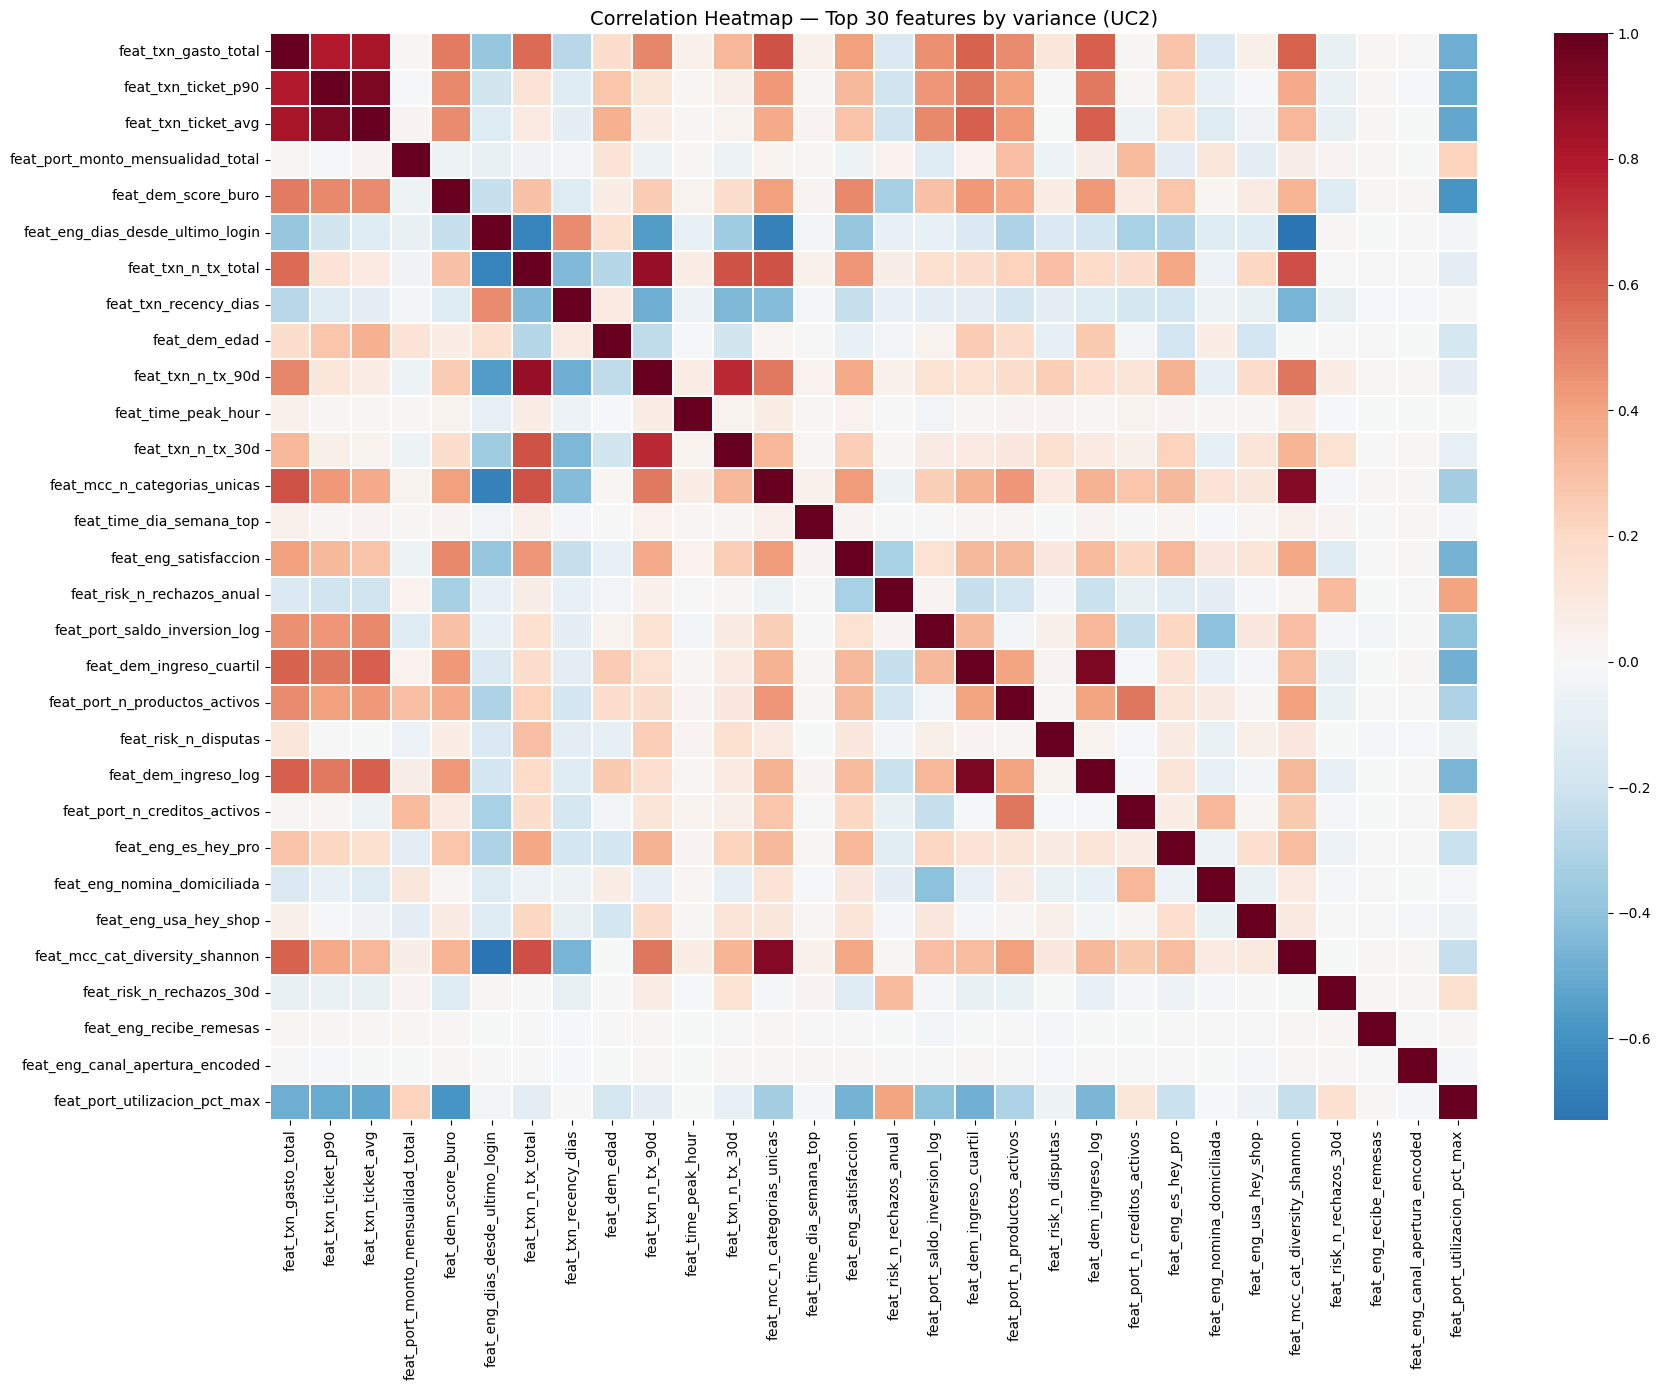

Heatmap saved.
CPU times: user 311 ms, sys: 26 ms, total: 337 ms
Wall time: 346 ms


In [20]:
%%time
# ── Heatmap de correlaciones (top 30 numéricas por varianza) ──────────────────
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'user_id']

# Select top 30 by variance to keep heatmap readable
variances  = df_features[numeric_cols].var().sort_values(ascending=False)
top30_cols = variances.head(30).index.tolist()

corr_matrix = df_features[top30_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    cmap='RdBu_r', center=0,
    annot=False, linewidths=0.3,
    ax=ax
)
ax.set_title('Correlation Heatmap — Top 30 features by variance (UC2)', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'uc2_correlation_heatmap.png', dpi=120)
plt.show()
print("Heatmap saved.")

## 11. Persistencia

Save the feature matrix as parquet for downstream use in the clustering notebook (`12_clustering_digital_twin_bi.ipynb`).

In [21]:
output_path = OUTPUT_DIR / "feat_uc2_personas.parquet"
df_features.to_parquet(output_path, index=False)
print(f"✅ feat_uc2_personas.parquet: {df_features.shape}")
print(f"   Saved to: {output_path}")
print(f"   File size: {output_path.stat().st_size / 1024:.1f} KB")

✅ feat_uc2_personas.parquet: (15025, 68)
   Saved to: /Users/diegodq/Documents/dev/datamoles/Datathon-2026/outputs/features/feat_uc2_personas.parquet
   File size: 2225.5 KB


In [22]:
# ── Quick smoke test: reload and verify ───────────────────────────────────────
df_check = pd.read_parquet(output_path)
assert df_check.shape == df_features.shape, "Shape mismatch after reload!"
assert 'user_id' in df_check.columns, "user_id missing after reload!"
print(f"✅ Reload OK — shape: {df_check.shape}")
df_check.head(3)

✅ Reload OK — shape: (15025, 68)


,user_id,feat_dem_edad,feat_dem_edad_bin,feat_dem_sexo_H,feat_dem_sexo_M,feat_dem_sexo_SE,feat_dem_ingreso_log,feat_dem_ingreso_cuartil,feat_dem_antiguedad_dias,feat_dem_score_buro,...,feat_chn_share_app_android,feat_chn_share_app_huawei,feat_chn_share_pos,feat_chn_share_codi,feat_chn_share_cajero,feat_risk_n_rechazos_anual,feat_risk_n_rechazos_30d,feat_risk_n_disputas,feat_risk_pct_atipicas,feat_risk_pct_reintento
0,USR-00001,21,<26,False,True,False,10.106469,3.0,NaN,527,...,0.480769,0.038462,0.134615,0.038462,0.0,3.0,NaN,NaN,0.0,0.038462
1,USR-00002,18,<26,False,True,False,9.852247,2.0,NaN,714,...,0.323529,0.058824,0.279412,0.014706,0.0,1.0,NaN,1.0,0.0,0.014706
2,USR-00003,23,<26,True,False,False,9.546884,1.0,NaN,454,...,0.295775,0.056338,0.295775,0.014085,0.0,4.0,1.0,2.0,0.0,0.014085
